# Creative Writing: Cost Efficiency Analysis

Computes throughput and effective cost per 1M tokens for each open-source evaluator model
using aggregated execution logs, then compares against the Claude Sonnet 4.6 proprietary baseline.

**Formulas (Section 4.4 of paper)**

$$\text{Throughput (tok/s)} = \frac{\sum_{i=1}^{N} \text{total\_tokens}_i}{\sum_{i=1}^{N} \text{latency\_ms}_i / 1000}$$

$$\text{Cost}_{1M} = \frac{1{,}000{,}000}{\text{Throughput} \times 3600} \times \text{Rate}_{\text{GPU}}$$

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120

## Config

In [2]:
LOGS_DIR = Path("../logs")

# H100 80GB GPU hourly rate range ($/hr)
# Based on 2026 market rates: RunPod ~$1.99, GMI Cloud ~$2.00, Lambda/Jarvislabs ~$2.99
GPU_RATE_LOW  = 2.0
GPU_RATE_HIGH = 3.5

# Claude Sonnet 4.6 API pricing (Anthropic)
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

CLAUDE_LOG = "llm_calls_claude-sonnet-4-6.jsonl"

def pretty_model(stem: str) -> str:
    s = stem.replace("llm_calls_", "")
    replacements = [
        ("-Instruct-2507", ""), ("-Instruct", ""), ("-BF16", ""),
        ("NVIDIA-", ""), ("-it", ""),
    ]
    for old, new in replacements:
        s = s.replace(old, new)
    return s

## Load logs and compute throughput

In [3]:
def parse_log(path: Path) -> dict:
    total_tokens_sum = latency_sum = prompt_sum = completion_sum = n_ok = n_total = 0
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            n_total += 1
            if e.get("status") == "ok":
                total_tokens_sum += e["total_tokens"]
                latency_sum      += e["latency_ms"] / 1000
                prompt_sum       += e["prompt_tokens"]
                completion_sum   += e["completion_tokens"]
                n_ok += 1
    return dict(
        n_ok=n_ok, n_total=n_total,
        total_tokens=total_tokens_sum, latency_s=latency_sum,
        prompt_tokens=prompt_sum, completion_tokens=completion_sum,
    )


# ── Baseline ────────────────────────────────────────────────────────────────
claude_raw = parse_log(LOGS_DIR / CLAUDE_LOG)
claude_cost_total = (
    claude_raw["prompt_tokens"]     * CLAUDE_PRICE_INPUT  / 1_000_000
    + claude_raw["completion_tokens"] * CLAUDE_PRICE_OUTPUT / 1_000_000
)
claude_blended = claude_cost_total / claude_raw["total_tokens"] * 1_000_000

print(f"Baseline — Claude Sonnet 4.6 (API)")
print(f"  Requests (ok):     {claude_raw['n_ok']:,}")
print(f"  Prompt tokens:     {claude_raw['prompt_tokens']:,}")
print(f"  Completion tokens: {claude_raw['completion_tokens']:,}")
print(f"  Total cost:        ${claude_cost_total:.4f}")
print(f"  Blended /1M tok:   ${claude_blended:.2f}")


# ── Open-source models ──────────────────────────────────────────────────────
rows = []
for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    throughput = raw["total_tokens"] / raw["latency_s"]
    cost_low  = (1_000_000 / (throughput * 3600)) * GPU_RATE_LOW
    cost_high = (1_000_000 / (throughput * 3600)) * GPU_RATE_HIGH
    rows.append(dict(
        model=pretty_model(log_file.stem),
        n_ok=raw["n_ok"],
        total_tokens=raw["total_tokens"],
        latency_s=raw["latency_s"],
        throughput=throughput,
        cost_low=cost_low,
        cost_high=cost_high,
        reduction_low=claude_blended / cost_low,
        reduction_high=claude_blended / cost_high,
    ))

df = pd.DataFrame(rows).sort_values("cost_low").reset_index(drop=True)

display_df = df[[
    "model", "n_ok", "throughput", "cost_low", "cost_high",
    "reduction_low", "reduction_high"
]].copy()
display_df.columns = [
    "Model", "N (ok)", "Throughput (tok/s)",
    "Cost/1M low ($)", "Cost/1M high ($)",
    "Reduction (low)", "Reduction (high)"
]
display_df["Throughput (tok/s)"] = display_df["Throughput (tok/s)"].map("{:.0f}".format)
display_df["Cost/1M low ($)"]    = display_df["Cost/1M low ($)"].map("${:.3f}".format)
display_df["Cost/1M high ($)"]   = display_df["Cost/1M high ($)"].map("${:.3f}".format)
display_df["Reduction (low)"]    = display_df["Reduction (low)"].map("{:.1f}x".format)
display_df["Reduction (high)"]   = display_df["Reduction (high)"].map("{:.1f}x".format)

print(f"\nGPU rate: ${GPU_RATE_LOW}–${GPU_RATE_HIGH}/hr | Claude blended baseline: ${claude_blended:.2f}/1M")
display(display_df)

Baseline — Claude Sonnet 4.6 (API)
  Requests (ok):     767
  Prompt tokens:     2,105,602
  Completion tokens: 250,822
  Total cost:        $10.0791
  Blended /1M tok:   $4.28

GPU rate: $2.0–$3.5/hr | Claude blended baseline: $4.28/1M


,Model,N (ok),Throughput (tok/s),Cost/1M low ($),Cost/1M high ($),Reduction (low),Reduction (high)
0,Llama-3.2-3B,811,2086,$0.266,$0.466,16.1x,9.2x
1,Nemotron-3-Nano-4B,767,1706,$0.326,$0.570,13.1x,7.5x
2,gemma-4-E2B,767,1525,$0.364,$0.638,11.7x,6.7x
3,Qwen3.5-4B,767,1262,$0.440,$0.770,9.7x,5.6x
4,Qwen3-4B,767,1250,$0.444,$0.778,9.6x,5.5x
5,gemma-4-E4B,767,1012,$0.549,$0.960,7.8x,4.5x


## Cost per 1M tokens — bar chart

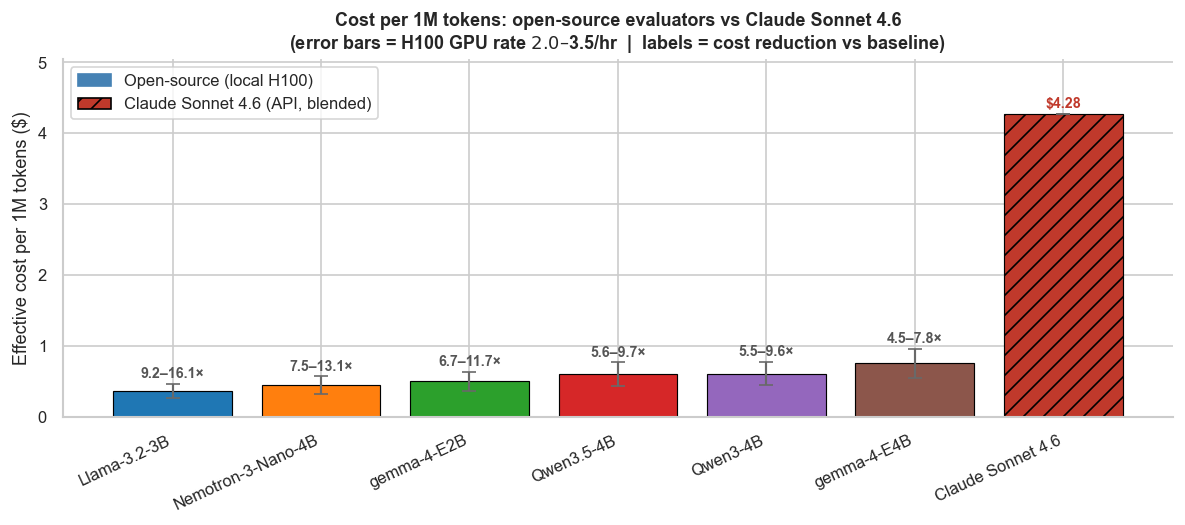

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))

os_models  = df["model"].tolist()
os_mids    = ((df["cost_low"] + df["cost_high"]) / 2).tolist()
os_errs    = ((df["cost_high"] - df["cost_low"]) / 2).tolist()

all_labels = os_models + ["Claude Sonnet 4.6"]
all_mids   = os_mids + [claude_blended]
all_errs   = os_errs + [0]

x = np.arange(len(all_labels))
os_palette = sns.color_palette("tab10", n_colors=len(os_models))
all_colors = list(os_palette) + ["#c0392b"]

bars = ax.bar(x, all_mids, yerr=all_errs, capsize=4,
              color=all_colors, edgecolor="black", linewidth=0.7,
              error_kw=dict(elinewidth=1.3, ecolor="dimgrey"),
              hatch=[""] * len(os_models) + ["//"])

# Reduction ratio labels on open-source bars only
for i, (bar, mid, err, red_low, red_high) in enumerate(
        zip(bars, os_mids, os_errs, df["reduction_low"], df["reduction_high"])):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mid + err + 0.04,
            f"{red_high:.1f}–{red_low:.1f}×",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#555")

# Dollar value label on Claude bar
claude_bar = bars[-1]
ax.text(claude_bar.get_x() + claude_bar.get_width() / 2,
        claude_blended + 0.04,
        f"${claude_blended:.2f}",
        ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#c0392b")

ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=25, ha="right")
ax.set_ylabel("Effective cost per 1M tokens ($)")
ax.set_ylim(0, claude_blended * 1.18)
ax.set_title("Cost per 1M tokens: open-source evaluators vs Claude Sonnet 4.6\n"
             f"(error bars = H100 GPU rate ${GPU_RATE_LOW}–${GPU_RATE_HIGH}/hr  |  labels = cost reduction vs baseline)",
             fontweight="bold")

os_patch     = mpatches.Patch(color="steelblue", label="Open-source (local H100)")
claude_patch = mpatches.Patch(facecolor="#c0392b", hatch="//", edgecolor="black",
                               label="Claude Sonnet 4.6 (API, blended)")
ax.legend(handles=[os_patch, claude_patch], loc="upper left")

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

## Total run cost (full dataset)

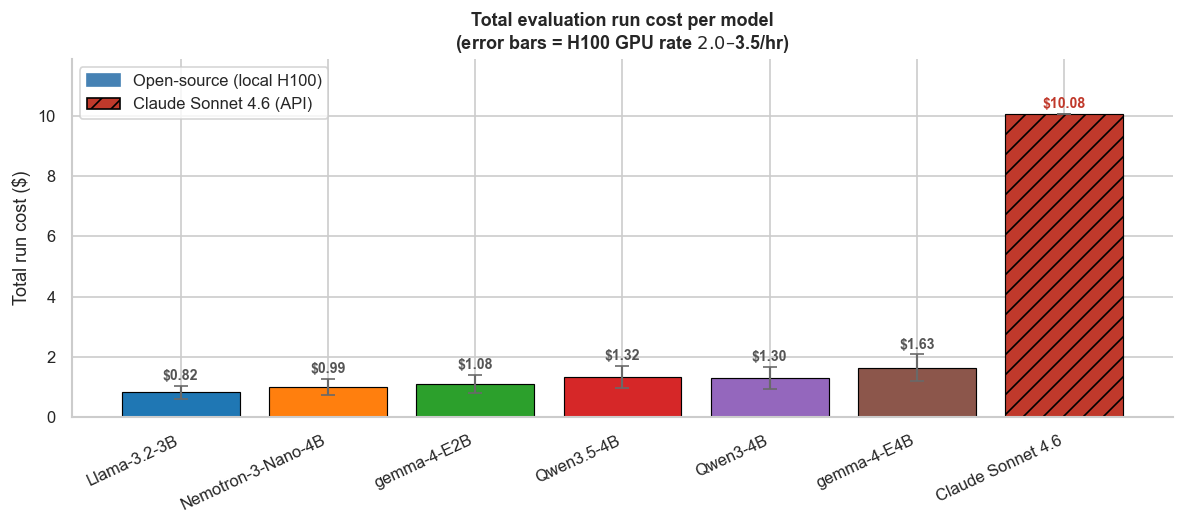

,Model,GPU hours,Run cost,Savings vs Claude baseline
0,Llama-3.2-3B,0.297567,$0.60 – $1.04,$9.04 – $9.48
1,Nemotron-3-Nano-4B,0.359049,$0.72 – $1.26,$8.82 – $9.36
2,gemma-4-E2B,0.393654,$0.79 – $1.38,$8.70 – $9.29
3,Qwen3.5-4B,0.481607,$0.96 – $1.69,$8.39 – $9.12
4,Qwen3-4B,0.471095,$0.94 – $1.65,$8.43 – $9.14
5,gemma-4-E4B,0.592704,$1.19 – $2.07,$8.00 – $8.89


In [5]:
run_rows = []
for _, row in df.iterrows():
    gpu_hours = row["latency_s"] / 3600
    run_rows.append(dict(
        model=row["model"],
        gpu_hours=gpu_hours,
        run_cost_low=gpu_hours * GPU_RATE_LOW,
        run_cost_high=gpu_hours * GPU_RATE_HIGH,
    ))

run_df = pd.DataFrame(run_rows)

fig, ax = plt.subplots(figsize=(10, 4.5))

run_mids = ((run_df["run_cost_low"] + run_df["run_cost_high"]) / 2).tolist()
run_errs = ((run_df["run_cost_high"] - run_df["run_cost_low"]) / 2).tolist()

all_run_labels = run_df["model"].tolist() + ["Claude Sonnet 4.6"]
all_run_mids   = run_mids + [claude_cost_total]
all_run_errs   = run_errs + [0]

x = np.arange(len(all_run_labels))
all_colors = list(sns.color_palette("tab10", n_colors=len(run_df))) + ["#c0392b"]

bars = ax.bar(x, all_run_mids, yerr=all_run_errs, capsize=4,
              color=all_colors, edgecolor="black", linewidth=0.7,
              error_kw=dict(elinewidth=1.3, ecolor="dimgrey"),
              hatch=[""] * len(run_df) + ["//"])

for bar, mid, err in zip(bars[:-1], run_mids, run_errs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mid + err + claude_cost_total * 0.01,
            f"${mid:.2f}",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#555")

claude_bar = bars[-1]
ax.text(claude_bar.get_x() + claude_bar.get_width() / 2,
        claude_cost_total + claude_cost_total * 0.01,
        f"${claude_cost_total:.2f}",
        ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#c0392b")

ax.set_xticks(x)
ax.set_xticklabels(all_run_labels, rotation=25, ha="right")
ax.set_ylabel("Total run cost ($)")
ax.set_ylim(0, claude_cost_total * 1.18)
ax.set_title("Total evaluation run cost per model\n"
             f"(error bars = H100 GPU rate ${GPU_RATE_LOW}–${GPU_RATE_HIGH}/hr)",
             fontweight="bold")

os_patch     = mpatches.Patch(color="steelblue", label="Open-source (local H100)")
claude_patch = mpatches.Patch(facecolor="#c0392b", hatch="//", edgecolor="black",
                               label="Claude Sonnet 4.6 (API)")
ax.legend(handles=[os_patch, claude_patch], loc="upper left")

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

run_df["run_cost_range"] = run_df.apply(
    lambda r: f"${r['run_cost_low']:.2f} – ${r['run_cost_high']:.2f}", axis=1
)
run_df["savings_vs_baseline"] = run_df.apply(
    lambda r: f"${claude_cost_total - r['run_cost_high']:.2f} – ${claude_cost_total - r['run_cost_low']:.2f}",
    axis=1
)
display(run_df[["model", "gpu_hours", "run_cost_range", "savings_vs_baseline"]].rename(columns={
    "model": "Model",
    "gpu_hours": "GPU hours",
    "run_cost_range": "Run cost",
    "savings_vs_baseline": "Savings vs Claude baseline",
}))